<h1><center>CMSE 381 Project</center></h1>
<h3><center>Siddak Marwaha</center></h3>
<h3><center>Dataset: Star dataset to predict star types</center></h3>

# Introduction
Stars are integral to our understanding of the universe. Their properties such as temperature, luminosity, and spectral classification provide insights about the universe. This project explores the Star Dataset (https://www.kaggle.com/datasets/deepu1109/star-dataset?resource=download), a dataset of 240 stars, to build predictive models that enhance our understanding of stellar characteristics.

The project focuses on two primary tasks:

- Regression Analysis: Predicting a star’s temperature based on its physical properties. Temperature plays a fundamental role in astrophysics, influencing a star's spectral class, absolute magnitude, etc.
- Classification Task: Predicting the star type using a combination of numerical and categorical features. Understanding star types is crucial for categorizing stellar objects and studying their physical behavior.

By leveraging regression and classification techniques, we aim to find patterns in the data and evaluate model performance using metrics like R^2 and Mean Squared Error (MSE).

# 1. Regression for predicting temperature using star features

### Description of the data

This dataset represents a collection of astronomical data for 240 stars across six categories based on stellar classification. The data includes both physical properties (e.g., temperature, luminosity, radius) and categorical attributes (e.g., star color, spectral class).

- Dataset Characteristics:
    - Type: Multivariate
    - Subject Area: Astronomy
    - Associated Tasks: Regression and Classification
    - Data Format: Mixed (Numerical, Categorical)
    - Number of Instances: 240 stars
    - Number of Features: 6 (excluding the target variable)
    
    
- Features and Target Variable:
    - Temperature (float; feature): Absolute temperature of the star, measured in Kelvin (K). Unit: Kelvin (K).
    - Luminosity (float; feature): Relative luminosity of the star compared to the Sun's luminosity (L/L⊙). Unit: Sun Luminosity Ratio (L/L⊙)
    - Radius (float; feature): Relative radius of the star compared to the Sun's radius (R/R⊙). Unit: Sun Radius Ratio (R/R⊙).
    - Absolute Magnitude (float; feature): The brightness of the star as seen from a standard distance. Unit: Magnitude (Mv).
    - Star Color (string; feature): Describes the color of the star based on its spectral characteristics. Example: Red, Blue, Blue-White, Yellow, etc.
    - Spectral Class (categorical; feature): Classification of stars based on their spectral characteristics. Categories: O, B, A, F, G, K, M.
    - Star Type (integer; target): Classification of the star into one of six stellar types:
        - 0: Brown Dwarf
        - 1: Red Dwarf
        - 2: White Dwarf
        - 3: Main Sequence
        - 4: Supergiant
        - 5: Hypergiant
        - Unit: Integer class label.



### Standard Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### EDA

In [2]:
stars = pd.read_csv('6 class csv.csv')
stars.shape

(240, 7)

In [3]:
stars.head()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [4]:
stars.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [5]:
stars['Star color'].value_counts()

Red                   112
Blue                   55
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              3
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Blue                    1
Yellowish               1
Orange-Red              1
Blue white              1
Blue-White              1
Name: Star color, dtype: int64

In [6]:
# Standardize star color by lowercasing and stripping all values
stars['Star color'] = stars['Star color'].apply(lambda x:x.lower().strip())

In [7]:
stars['Star color'] = stars['Star color'].apply(lambda x:x.replace("-", " "))
stars['Star color'] = stars['Star color'].apply(lambda x:x.replace("yellowish", "yellow"))
stars['Star color'] = stars['Star color'].apply(lambda x:x.replace("whitish", "white"))
stars['Star color'] = stars['Star color'].apply(lambda x:x.replace("white yellow", "yellow white"))

In [8]:
stars['Star color'].value_counts()

red                   112
blue                   56
blue white             41
white                  12
yellow white           12
yellow                  3
orange                  2
pale yellow orange      1
orange red              1
Name: Star color, dtype: int64

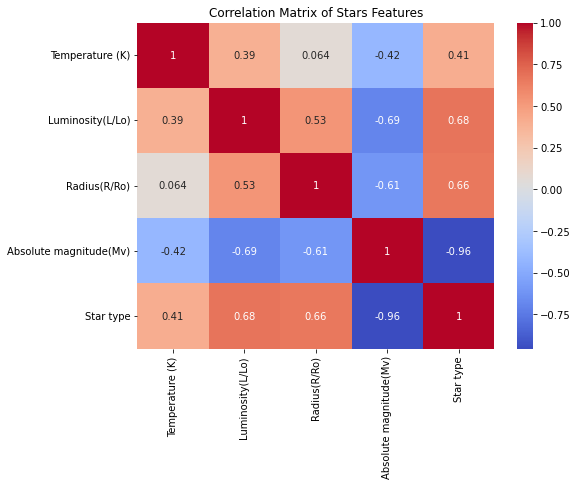

In [9]:
# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(stars.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Stars Features")
plt.show()

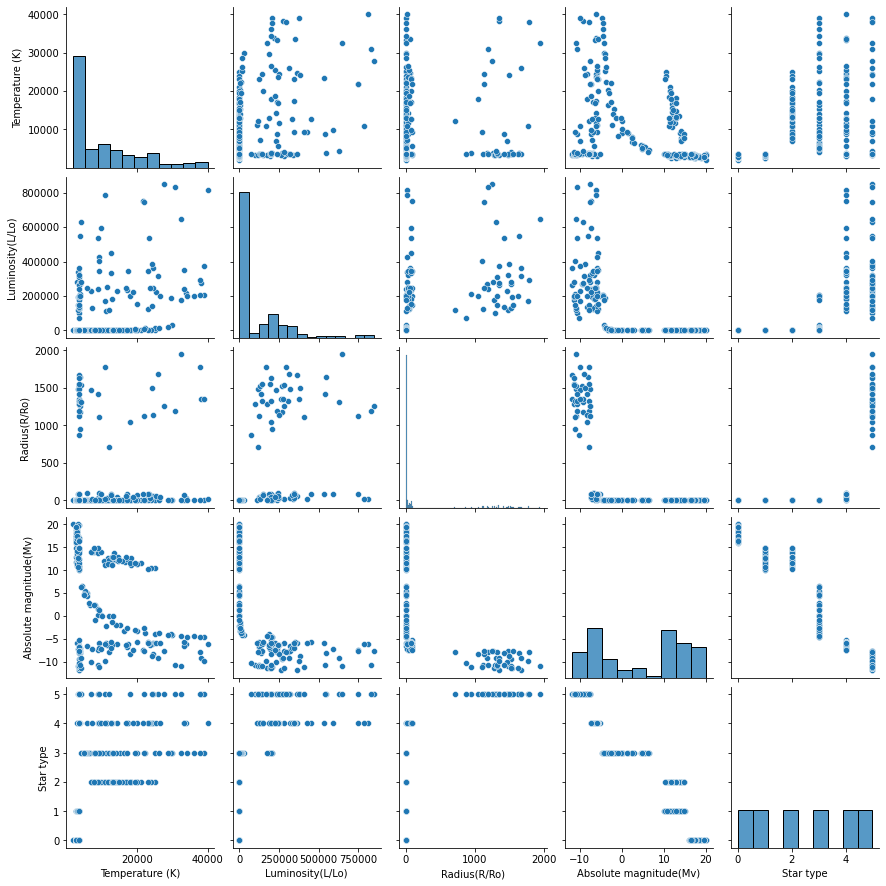

In [10]:
# Pair Plot to see relationships
sns.pairplot(stars)
plt.show()

Most feature variables are not that correlated with each other apart from:
- Absolute Magnitude:
    - Seemed correlated to
        1. Temperature
        2. Luminosity
        3. Star Type
    - A possible explanation for these correlations could be that since Absolute Magnitude measures the brightness of a star, which is fundamentally related to its temperature and luminosity. Additionally, Star Type categorization depends on these physical properties, naturally correlating it with Absolute Magnitude.

### Basic Linear Regression Model

In [11]:
# Define features and target variable
X = stars[['Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']]
y = stars['Temperature (K)']

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [13]:
# Standardize features for regularization techniques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# Baseline Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

In [15]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", round(mse,3))
print("R-squared:", round(r2, 3))

Mean Squared Error: 72079558.134
R-squared: 0.276


### Linear Regression K-Fold CV

In [16]:
# K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42) # Chose k = 5 since number_of_rows = 240 is divisible by 5, just for convenience
scores = cross_val_score(linear_model, X, y, cv=kf, scoring='neg_mean_squared_error')
print("Cross-Validated MSE:", np.average(np.absolute(scores)))


Cross-Validated MSE: 69251276.60233267


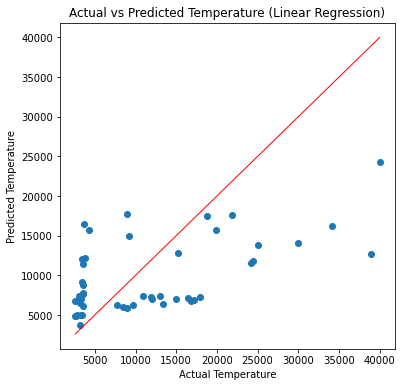

In [17]:
# Plotting the predictions vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature (Linear Regression)")
plt.show()

The graph plots actual temperature against predicted temperature from the linear regression model. The closer the points lie to the red line, the more accurate the model; deviations from this line indicate prediction errors. The R2 value is 0.276, which is very low so we did some modifications.

**Model Selection and Preprocessing**
- We implemented multiple regression techniques to predict stellar temperature:

    - Linear Regression serves as the baseline model to establish a benchmark for performance.
    - Polynomial Regression captures non-linear relationships, which are common in astrophysics.
    - Ridge Regression applies L2 regularization to prevent overfitting and improve generalization. Preprocessing includes scaling numerical features and encoding categorical features to make them suitable for regression. Cross-validation with k=5 splits ensures that the models are evaluated well and reduces the risk of overfitting.


### Ridge Regression
To address the issues observed in the baseline Linear Regression model, we applied Ridge Regression. Ridge introduces L2 regularization, which improves the model by reducing any overfitting.

We tuned alpha using cross-validation. A range of alpha values was tested, and we found the optimal value to be approximately 10, which minimized the cross-validated MSE.

In [18]:
# Baseline Ridge Regression Model Evaluation with alpha = 1
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Mean Squared Error:", round(ridge_mse,3))
print("R-squared:", round(ridge_r2,3))

Mean Squared Error: 72141413.227
R-squared: 0.275


In [19]:
# Tuning Ridge alpha using Cross-Validation
alphas = np.logspace(-3, 2, 100)
ridge_cv_mse = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    cv_mse = cross_val_score(ridge, X_train_scaled, y_train, cv=kf, scoring='neg_mean_squared_error')
    ridge_cv_mse.append(-cv_mse.mean())

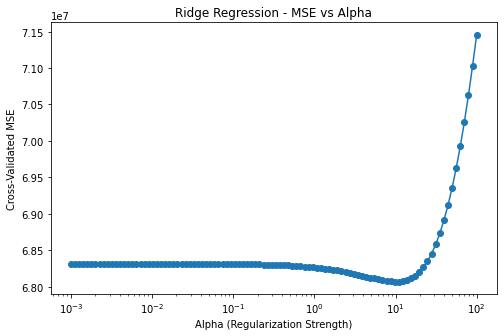

In [20]:
# Plot Ridge CV results
plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_cv_mse, marker='o')
plt.xscale('log')
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Cross-Validated MSE")
plt.title("Ridge Regression - MSE vs Alpha")
plt.show()

#### Zooming In

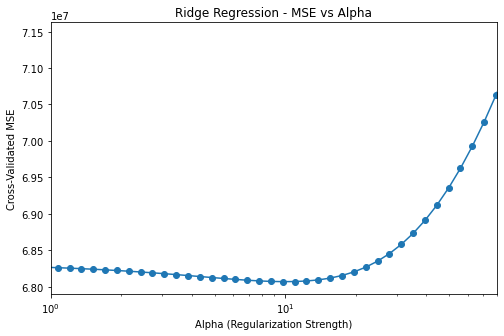

Optimal Alpha: 9.770099572992246


In [21]:
# Plot Ridge CV results
plt.figure(figsize=(8, 5))
plt.plot(alphas, ridge_cv_mse, marker='o')
plt.xscale('log')
plt.xlim(1, 80)
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Cross-Validated MSE")
plt.title("Ridge Regression - MSE vs Alpha")
plt.show()

# Identify the optimal alpha
optimal_alpha = alphas[np.argmin(ridge_cv_mse)]
print("Optimal Alpha:", optimal_alpha)

Here, we can see that alpha = 10 has the lowest MSE.

In [22]:
# Ridge Regression with Cross-Validation
ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Mean Squared Error:", round(ridge_mse,3))
print("R-squared:", round(ridge_r2,3))

Mean Squared Error: 72756341.697
R-squared: 0.269


### Polynomial Regression
While Linear and Ridge Regression captured linear relationships, Polynomial Regression was used to model non-linear relationships. By using Polynomial Features of degree 2, we observed an improvement in R-squared values. 

Feature scaling was important to prevent high-degree polynomial terms from dominating. Encoding categorical variables like "Star Color", "Spectral Class", and "Star type" also contributed to the model's ability to explain variance in temperature predictions.

Mean Squared Error (Degree 2): 68603104.779
R-squared (Degree 2): 0.311


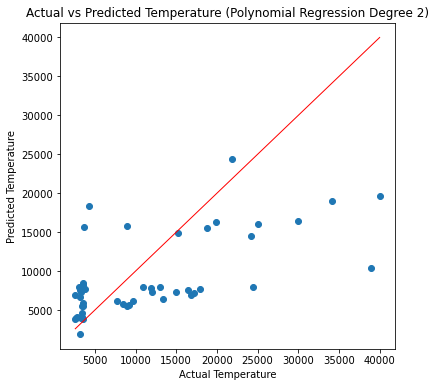

In [23]:
# Apply Baseline PolynomialFeatures with degree 2 and without encoding
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit Polynomial Regression Model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict on the test set
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluate the Polynomial Regression Model
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Mean Squared Error (Degree 2): {round(mse_poly, 3)}")
print(f"R-squared (Degree 2): {round(r2_poly, 3)}")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature (Polynomial Regression Degree 2)")
plt.show()


### Feature encoding

In [24]:
# Copy original dataset
stars_encoded = stars.copy()

# Label Encoding for categorical features
le_color = LabelEncoder()
stars_encoded['Star Color Encoded'] = le_color.fit_transform(stars_encoded['Star color'])

le_spectral = LabelEncoder()
stars_encoded['Spectral Class Encoded'] = le_spectral.fit_transform(stars_encoded['Spectral Class'])

# Define features and target variable
X = stars_encoded[['Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)', 
                   'Star Color Encoded', 'Spectral Class Encoded', 'Star type']]
y = stars_encoded['Temperature (K)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

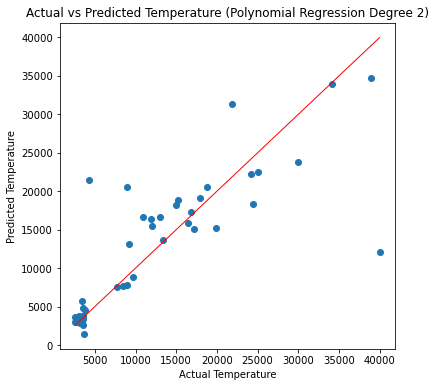

In [25]:
# Polynomial Features with degree 2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Train Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict and evaluate
y_pred_poly = poly_model.predict(X_test_poly)

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=1)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature (Polynomial Regression Degree 2)")
plt.show()

In [26]:
# Use cross_val_score for Polynomial Regression
poly_cv_mse = -cross_val_score(poly_model, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
poly_cv_r2 = cross_val_score(poly_model, X_train_poly, y_train, cv=kf, scoring='r2')

print(f"Polynomial Regression CV Mean Squared Error: {round(poly_cv_mse.mean(), 3)}")
print(f"Polynomial Regression CV R-squared: {round(poly_cv_r2.mean(), 3)}")

Polynomial Regression CV Mean Squared Error: 47328579.277
Polynomial Regression CV R-squared: 0.455


In [27]:
# Ridge Regression with K-Fold CV
ridge_model_poly = Ridge(alpha=10)

# Use cross_val_score for Ridge Regression
ridge_cv_mse = -cross_val_score(ridge_model_poly, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
ridge_cv_r2 = cross_val_score(ridge_model_poly, X_train_poly, y_train, cv=kf, scoring='r2')

print(f"Ridge Regression CV Mean Squared Error: {round(ridge_cv_mse.mean(), 3)}")
print(f"Ridge Regression CV R-squared: {round(ridge_cv_r2.mean(), 3)}")

Ridge Regression CV Mean Squared Error: 23829516.351
Ridge Regression CV R-squared: 0.728


### Interpretation of Results
The Ridge Regression model on polynomial features with Kfold Cross Validation achieved the highest R-squared value of 0.728, indicating that it effectively captured the non-linear relationships between stellar properties and temperature. The inclusion of encoded categorical features and polynomial terms greatly improved predictive accuracy.

### Limitations
Despite the improved performance, we did not have important features like mass, central density, central pressure, etc. which could be used to improve the performance further.

# 2. Classification for the type of star based on star features

The goal of this analysis is to classify stars into their respective types based on their physical and categorical properties. Accurate classification of star types can contribute significantly to astrophysical research by helping scientists categorize stars efficiently and study their underlying properties.

We will implement two classification models:

- Logistic Regression
- Random Forest Classifier

We will compare their performances using metrics such as accuracy, precision, recall, F1-score, and confusion matrix. Model improvements and parameter tuning will be addressed using techniques like K-fold Cross-Validation and Grid Search.

### EDA

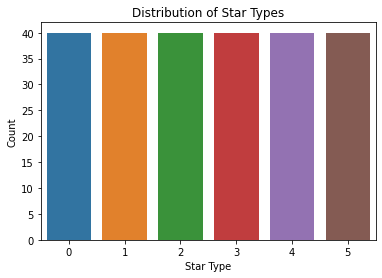

In [28]:
sns.countplot(x='Star type', data=stars)
plt.title("Distribution of Star Types")
plt.xlabel("Star Type")
plt.ylabel("Count")
plt.show()

The dataset has a reasonably balanced distribution of star types, making it suitable for classification.

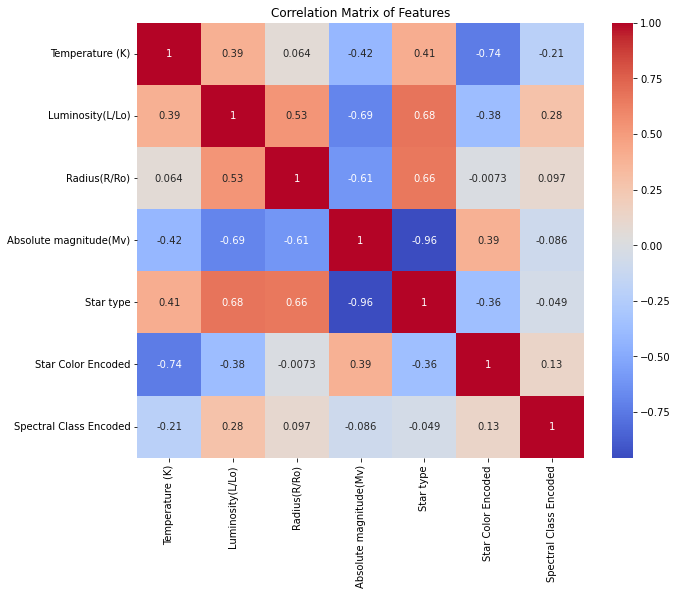

In [29]:
# Check for correlations including the encoded variables
corr_matrix = stars_encoded.corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Features")
plt.show()

The correlation matrix shows a comparatively high negative correlation of -0.74 between the temperature and star color. The negative correlation between temperature and star color arises because cooler stars tend to appear red, while hotter stars are bluer.

### Logistic Regression

Preprocessing the data again to avoid any confusion

In [30]:
# Split the dataset into features and target
X = stars_encoded.drop("Star type", axis=1)
y = stars_encoded["Star type"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, stratify=y, random_state=12)

In [31]:
# Encode categorical features using LabelEncoder for simplicity
le = LabelEncoder()

# Apply encoding to categorical features (object type)
for col in X_train.select_dtypes(include="O").columns:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [32]:
# Standardize numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Model Implementation**
- We use Logistic Regression as a baseline classification model.

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.92      0.92      0.92        12
           2       1.00      1.00      1.00        12
           3       1.00      0.92      0.96        12
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00        12

    accuracy                           0.97        72
   macro avg       0.97      0.97      0.97        72
weighted avg       0.97      0.97      0.97        72



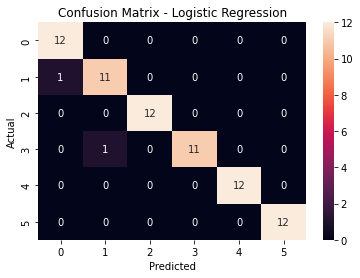

In [33]:
# Logistic Regression Model
logreg = LogisticRegression(random_state=12)
logreg.fit(X_train_scaled, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))

# Confusion Matrix
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)
sns.heatmap(conf_matrix_logreg, annot=True)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Results**
- Accuracy: 0.97
- Precision, Recall, F1-score: The model performs pretty well for all star types with the lowest precision, recall, or f1-score being 0.92.

**K-Fold Cross-Validation**
- To ensure comparative analysis, we evaluate the model using a 5 fold CV.

In [34]:
kf = KFold(n_splits=5, shuffle=True, random_state=12)
logreg_cv_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print("Logistic Regression CV Accuracy:", logreg_cv_scores.mean())

Logistic Regression Cross-Validation Accuracy: 0.9406417112299466


### Random Forest Classifier
**Model Implementation and Hyperparameter Tuning**
- Random Forest is a method that captures pretty complex relationships between features and the target variable by working like a group of decision trees. We use Grid Search CV for hyperparameter tuning.

In [35]:
# Random Forest Classifier
rf = RandomForestClassifier(random_state=12)

# Hyperparameter Tuning with GridSearchCV
param_grid = {
    'n_estimators': [20, 50, 70],
    'max_depth': [3, 7, 10],
}

grid_search = GridSearchCV(rf, param_grid, cv=kf, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
rf_best = grid_search.best_estimator_

Best Parameters: {'max_depth': 7, 'n_estimators': 50}


In [36]:
# Predictions
y_pred_rf = rf_best.predict(X_test_scaled)

# Evaluation
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00        12
           4       1.00      1.00      1.00        12
           5       1.00      1.00      1.00        12

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



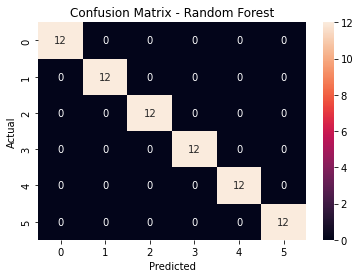

In [37]:
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Results**
- Accuracy: 1.0
- Precision, Recall, F1-score: Better performance compared to Logistic Regression, with 0 misclassifications.

**K-Fold Cross-Validation**

In [38]:
rf_cv_scores = cross_val_score(rf_best, X_train_scaled, y_train, cv=kf, scoring='accuracy')
print("Random Forest CV Accuracy:", rf_cv_scores.mean())

Random Forest Cross-Validation Accuracy: 1.0


### Interpretation of Results
Random Forest outperformed Logistic Regression in accuracy, as seen from the cross validation scores and classification reports. Random Forest helps capture non-linear relationships between features and star type.

### Limitations
While the model performed perfectly, there aren't enough datapoints to be able to use this model commercially. If we had a larger sample of stars, the accuracy metric would hold higher importance.